# Some terminology:

**CASH-IN**: is the process of increasing the balance of
account by paying in cash to a merchant.

**CASH-OUT**: is the opposite process of CASH-IN, it
means to withdraw cash from a merchant which decreases
the balance of the account.

**DEBIT**: is similar process than CASH-OUT and involves sending the money from the mobile money service
to a bank account.

**PAYMENT**: is the process of paying for goods or services to merchants which decreases the balance of the account and increases the balance of the receiver.

**TRANSFER**: is the process of sending money to another user of the service through the mobile money platform

# Features:

**step**: Step denotes a portion of the time period

**type**: Type of the transaction

**amount**: Amount involved in transaction

**nameOrig**: Name of the source account

**oldbalanceOrg**: Old balance of source account

**newbalanceOrig**: New balance of source account

**nameDest**: Name of the target account

**oldbalanceDest**: Old balance of target account

**newbalanceDest**: New balance of target account

**isFraud**: 1 means is Fraud 0 means its not

**isFlaggedFraud**: Was the system able to detect if the transaction is fraud or not based on existing techniques



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
data_dir = Path("../data")
data_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(data_dir / "AIML Dataset.csv")

df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.info()
#The dataset contains 6362619 rows and 11 columns. With isFraud being the label (target variable) and the rest being features.

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [5]:
df["isFraud"].value_counts()
#This dataset is highly imbalanced, with only 8213 of the transactions being fraudulent.

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [6]:
df.isnull().sum()
#No null values in the dataset, which is good news for our model training.

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

<Axes: title={'center': 'Transaction Types'}, xlabel='Type', ylabel='Count'>

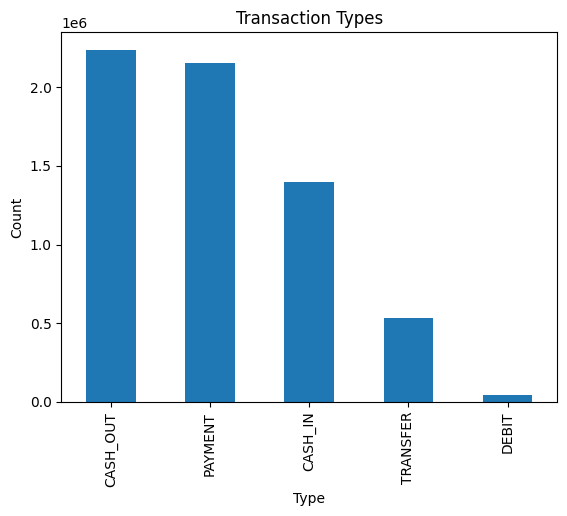

In [7]:
df["type"].value_counts().plot(kind="bar", title="Transaction Types", xlabel="Type", ylabel="Count")

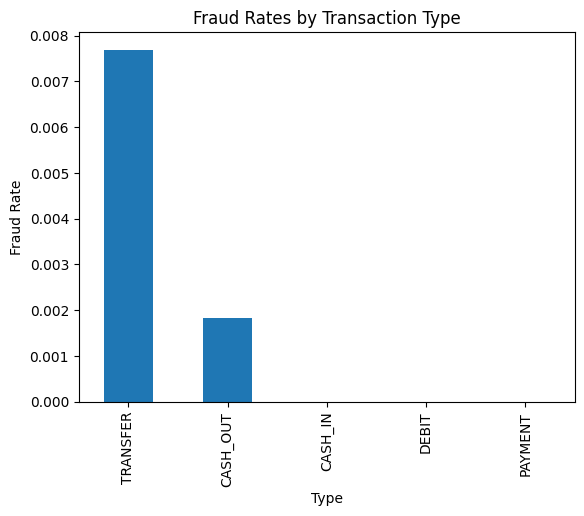

In [8]:
#Find fraud rates by type
fraud_rates = df.groupby("type")["isFraud"].mean().sort_values(ascending=False).plot(kind="bar", title="Fraud Rates by Transaction Type", 
                                                        xlabel="Type", ylabel="Fraud Rate")
#The highest fraud rates are observed in "TRANSFER" and "CASH_OUT" transaction types, 
# which may indicate that these types are more susceptible to fraudulent activities.

In [9]:
df["amount"].describe().astype(int)
#Lucky for us we have no negative transactions, but we do have some very large transactions (max of 92445516).

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

[Text(0.5, 1.0, 'Distribution of Log-Transformed Transaction Amounts'),
 Text(0.5, 0, 'Log(Amount + 1)'),
 Text(0, 0.5, 'Frequency')]

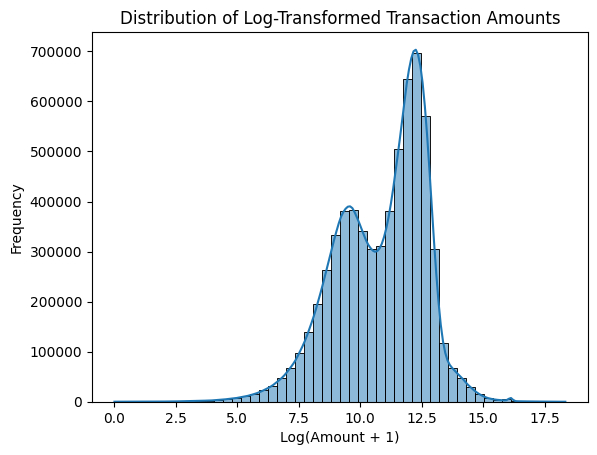

In [10]:
sns.histplot(np.log1p(df["amount"]), bins=50, kde=True).set(title="Distribution of Log-Transformed Transaction Amounts",
                                                             xlabel="Log(Amount + 1)", ylabel="Frequency")
#Because the amount feature is highly skewed, we apply a log transformation to better visualize the distribution.

[Text(0.5, 1.0, 'Boxplot of Transaction Amounts by Fraud Status'),
 Text(0.5, 0, 'Is Fraud'),
 Text(0, 0.5, 'Amount')]

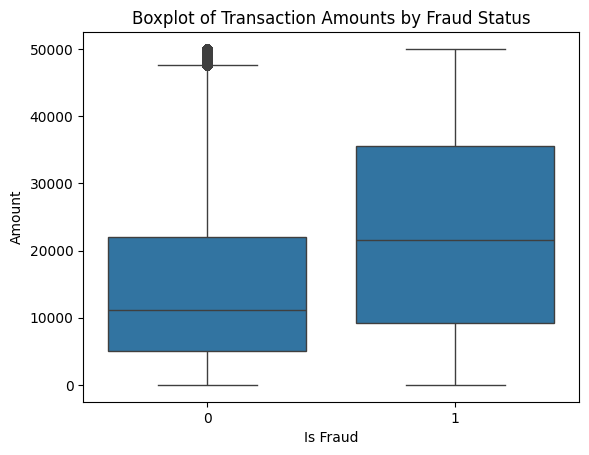

In [11]:
sns.boxplot(data=df[df["amount"] < 50000], x = "isFraud", y ="amount").set(title="Boxplot of Transaction Amounts by Fraud Status", 
                                                                        xlabel="Is Fraud", ylabel="Amount")
#This boxplot shows that fraudulent transactions tend to have higher amounts (under 50k) compared to non-fraudulent ones.

In [12]:
df["balanceDiffOriginal"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]

In [13]:
(df["balanceDiffOriginal"] < 0).sum()
#There are 1399253 cases where the original balance difference is negative.

np.int64(1399253)

In [14]:
(df["balanceDiffDest"] < 0).sum()
#There are 1238864 cases where the destination balance difference is negative.

np.int64(1238864)

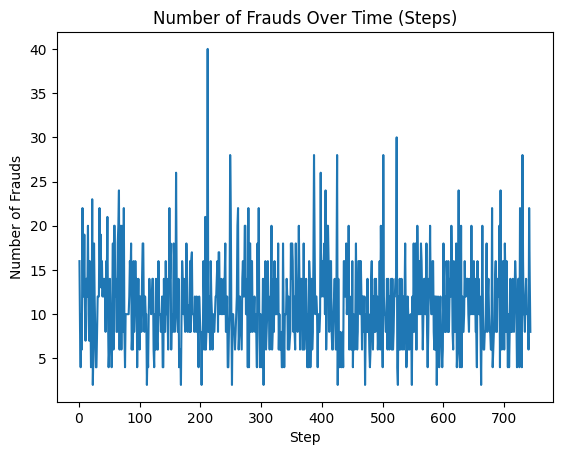

In [15]:
frauds_per_step = df[df["isFraud"] == 1]["step"].value_counts().sort_index().plot(kind="line", title="Number of Frauds Over Time (Steps)",
                                                                                   xlabel="Step", ylabel="Number of Frauds")
#This line plot shows the number of fraudulent transactions over time (steps). By analyzing this plot, 
#we can not identify any trends or patterns in fraudulent activity, which indicates that it is not time-dependent.
#Because of this, we will drop the "step" feature from our model training, as it does not provide useful information for fraud detection.

In [16]:
df.drop(columns=["step"], inplace=True) #Inplace=True to drop the column from the original dataframe.

In [17]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOriginal,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [18]:
top_senders = df["nameOrig"].value_counts().head(10)
top_senders

nameOrig
C2098525306    3
C400299098     3
C1999539787    3
C1065307291    3
C545315117     3
C1976208114    3
C1784010646    3
C1530544995    3
C1902386530    3
C1677795071    3
Name: count, dtype: int64

In [19]:
top_receivers = df["nameDest"].value_counts().head(10)
top_receivers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [20]:
name_fraud_users = df[df["isFraud"] == 1]["nameOrig"].value_counts().head(10)
name_fraud_users

nameOrig
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C1118430673    1
C749981943     1
C1334405552    1
C467632528     1
C1364127192    1
Name: count, dtype: int64

In [21]:
fraud_users = df[df["isFraud"] == 1]
fraud_users

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOriginal,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0,181.00,0.00
3,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0,181.00,-21182.00
251,TRANSFER,2806.00,C1420196421,2806.00,0.0,C972765878,0.00,0.00,1,0,2806.00,0.00
252,CASH_OUT,2806.00,C2101527076,2806.00,0.0,C1007251739,26202.00,0.00,1,0,2806.00,-26202.00
680,TRANSFER,20128.00,C137533655,20128.00,0.0,C1848415041,0.00,0.00,1,0,20128.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0,339682.13,339682.13
6362616,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0,6311409.28,0.00
6362617,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0,6311409.28,6311409.27
6362618,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0,850002.52,0.00


In [22]:
fraud_types = df[df["type"].isin(["TRANSFER", "CASH_OUT"])]

[Text(0.5, 1.0, 'Fraud Counts by Transaction Type')]

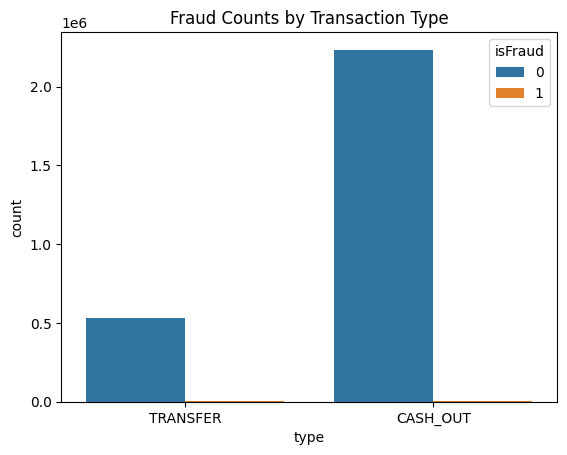

In [23]:
sns.countplot(data=fraud_types, x="type", hue="isFraud").set(title="Fraud Counts by Transaction Type")
#This count plot shows the distribution of fraudulent and non-fraudulent transactions for the "TRANSFER" and "CASH_OUT" types.
#Cash-out transactions have a higher count of frauds compared to transfers, which may indicate that cash-out transactions 
# are more vulnerable to fraud.

In [24]:
corr = df[["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]].corr()
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


[Text(0.5, 1.0, 'Correlation Heatmap of Numerical Features')]

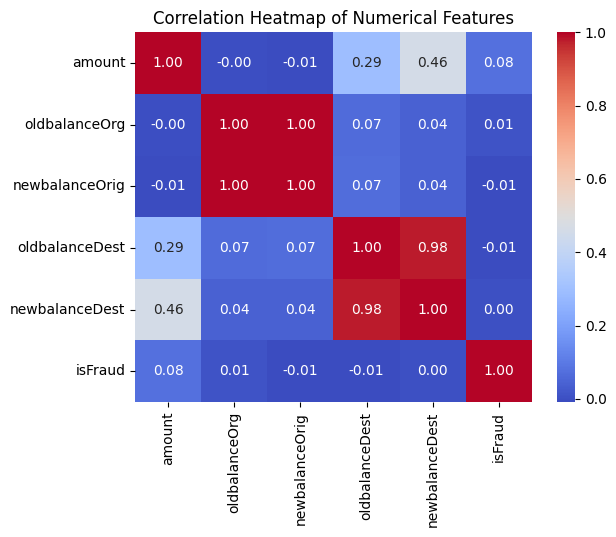

In [25]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f").set(title="Correlation Heatmap of Numerical Features")
#annot=True to display the correlation values on the heatmap, and cmap="coolwarm" to use a diverging color palette 
# that highlights both positive and negative correlations.
#fmt=".2f" to format the correlation values to two decimal places for better readability.

#Note: Correlation can take up values between -1 and 1, where:
#-1 indicates a perfect negative correlation (as one variable increases, the other decreases).
#0 indicates no correlation (the variables do not have a linear relationship).
#1 indicates a perfect positive correlation (as one variable increases, the other also increases).

In [26]:
zero_after_transfer = df[(df["oldbalanceOrg"] > 0) & (df["newbalanceOrig"] == 0) & (df["type"].isin(["TRANSFER", "CASH_OUT"]))]
zero_after_transfer

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOriginal,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0,181.00,0.00
3,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0,181.00,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.00,0.0,C476402209,5083.00,51513.44,0,0,15325.00,46430.44
19,TRANSFER,215310.30,C1670993182,705.00,0.0,C1100439041,22425.00,0.00,0,0,705.00,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.00,0.0,C932583850,6267.00,2719172.89,0,0,10835.00,2712905.89
...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0,339682.13,339682.13
6362616,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0,6311409.28,0.00
6362617,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0,6311409.28,6311409.27
6362618,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0,850002.52,0.00


## Let's get into feature engineering

Remember: We have a very high imbalanced dataset, which we need to treat

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [28]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOriginal,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [29]:
df_model = df.drop(["nameOrig", "nameDest", "isFlaggedFraud"], axis = 1)
df_model.head()
#We drop the "nameOrig" and "nameDest" columns because they are identifiers and do not provide useful information for our model.
#We also drop "isFlaggedFraud" because it is a feature that indicates whether a transaction was flagged as fraudulent by the system, 
# which could lead to data leakage if included

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOriginal,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [30]:
categorical = ["type"]
numeric = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "balanceDiffOriginal", "balanceDiffDest"]

In [31]:
y = df_model["isFraud"] #The target variable is the "isFraud" column, which indicates whether a transaction is fraudulent (1) or not (0).
X = df_model.drop("isFraud", axis=1) #The features are all the columns except "isFraud", which we drop to create our feature set X.

In [32]:
X["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)
#We split the dataset into training and testing sets, with 30% of the data reserved for testing.
#stratify=y ensures that the class distribution of the target variable is preserved in both the training and testing sets,
#  which is important for imbalanced datasets like ours.

In [34]:
preprocessor = ColumnTransformer( #We create a ColumnTransformer to apply different preprocessing steps to numeric and categorical features.
    transformers=[
        ("num", StandardScaler(), numeric), #We apply StandardScaler to the numeric features to standardize them (mean=0, std=1).
        ("cat", OneHotEncoder(drop='first'), categorical) #We apply OneHotEncoder to the categorical features to convert 
        #them into a format suitable for machine learning algorithms (which turns data into a binary numerical format (0 or 1)).
        # drop='first' is used to prevent perfect multicollinearity: when encoding k categorical values,
        # we create k-1 binary columns instead of k. This is because the last category can be perfectly
        # predicted from the others (e.g., if type_PAYMENT=0 and type_TRANSFER=0, then type_CASH_OUT=1).
        # While XGBoost handles this fine, it reduces dimensionality and improves model efficiency.
    ],
    remainder="drop"# We specify remainder="drop" to drop any columns that are not specified in the transformers list, 
    #ensuring that only the selected features are processed and used for modeling.
)

In [35]:
pipelineLR = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000))# we set class_weight="balanced" to handle the class imbalance 
        #in our dataset by assigning higher weights to the minority class (fraudulent transactions) during model training.
        #If we don't set class_weight="balanced", the model will most likely predict the majority class (non-fraudulent transactions) 
        # and perform poorly on the minority class (fraudulent transactions).
        # max_iter=1000 allows up to 1000 iterations for convergence. With class imbalance,
        # the model needs more iterations to properly distinguish fraudulent transactions.
    ])

In [36]:
pipelineLR.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [37]:
y_pred_LR = pipelineLR.predict(X_test)

In [38]:
print(classification_report(y_test, y_pred_LR))
#Recall means that out of all the actual fraudulent transactions, our model correctly identified 95% of them.
#We however have a low precision of 0.02, which means that out of all the transactions our model predicted as fraudulent, 
# only 11% were actually fraudulent. This means that while our model is good at identifying most of the fraudulent transactions 
# (high recall), it also has a high false positive rate, which could lead to many non-fraudulent transactions being flagged as fraudulent.

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.94      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [39]:
confusion_matrix(y_test, y_pred_LR)
#Layout:
#TP  FN
#FP  TN

array([[1805648,  100674],
       [    145,    2319]])

# Alternative Approach

Our Logistic Regression model achieves excellent recall (95%), effectively catching almost all fraudulent transactions. However, the low precision (2%) generates excessive false positives, flagging ~98 legitimate transactions for every fraudulent one detected.

While high recall is preferable to high precision in fraud detection (missing fraud is costlier than false alerts), the current false positive rate may impact user experience. We will explore XGBoost to potentially improve precision while accepting a minor recall trade-off, aiming for a better balance between fraud detection and alert fatigue.

In [40]:
import xgboost as xgb
from xgboost import XGBClassifier

pipelineXG = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(scale_pos_weight=99))# we set scale_pos_weight=99 to handle the class imbalance 
        #in our dataset by assigning higher weights to the minority class (fraudulent transactions) during model training.
    ])

In [41]:
pipelineXG.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [42]:
y_pred_XG = pipelineXG.predict(X_test)

In [43]:
print(classification_report(y_test, y_pred_XG))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.55      0.98      0.70      2464

    accuracy                           1.00   1908786
   macro avg       0.77      0.99      0.85   1908786
weighted avg       1.00      1.00      1.00   1908786



In [44]:
confusion_matrix(y_test, y_pred_XG)
#Layout:
#TP  FN
#FP  TN

array([[1904325,    1997],
       [     48,    2416]])

# XGBoost overview

XGBoost substantially outperforms Logistic Regression, achieving 55% precision (27.5x improvement) while maintaining 98% recall. With an F1-score of 0.71 and near-perfect accuracy, the model successfully balances fraud detection and false positive reduction. This performance is ideal for a production fraud detection system, delivering both effective fraud prevention and significantly lower false positive rate

In [45]:
#Let's export the XGBoost model to a file using joblib, which is a library for efficiently serializing Python objects.
import joblib
import os

# Cria a diretoria se não existir
os.makedirs("../model", exist_ok=True)

joblib.dump(pipelineXG, "../model/xgboost_fraud_model.pkl")

['../model/xgboost_fraud_model.pkl']